# 동해안 참다랑어 어장 변화와 TAC 제도 비판 — 웹 수집 리포트

**분석 질문**: 동해 표층수온 상승 추세와 참다랑어(다랑어류) 어획량 증가 추세는 함께 나타나는가, 그리고 그 증가가 현행 TAC 소진 시점과 시기적으로 충돌하는가?

**배경**: 기후변화로 인한 해수온 상승으로 참다랑어의 회유 경로와 분포 밀도가 근본적으로 변화했음에도, 현행 TAC 제도는 과거 통계·정적 할당 방식에 묶여 있어 자원 보호와 어업인 생계 지원 모두에서 한계를 보인다는 문제의식에서 출발한다.

**필요 컬럼**: 연-월, 동해 표층수온(평균/평년/편차), 참다랑어(다랑어류) 어획량·생산금액, (보조) 관련 논문 연도·인용수·주제

**수집 대상 및 방법**
| 데이터 | 대상 URL / 출처 | 방법 |
|---|---|---|
| 동해 표층수온 | https://oceanclimate.kr/sst/?start=2005-01&end=2026-05&area=all&var=mean&month=all | requests + BeautifulSoup |
| 참다랑어(다랑어류) 어획량 | KOSIS 어업생산동향조사 (어업별 품종별 통계) | 공식 CSV 다운로드 (조회 셀 2만 개 초과 제한으로 스크래핑 대신 사용) |
| 관련 논문 트렌드 (보조) | OpenAlex API | requests (공식 오픈 API) |

**윤리 점검**
- robots.txt 확인 완료 (oceanclimate.kr)
- 요청 간 `time.sleep()` 적용
- 로그인/개인정보 페이지 미사용
- Google Scholar는 robots.txt 및 이용약관상 자동화 접근이 금지되어 있어 수집 대상에서 제외, 대신 공식 오픈 API인 OpenAlex 사용

## 1. 라이브러리 불러오기

In [21]:
import requests
import time
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows는 'Malgun Gothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False

sns.set_style('whitegrid')

## 2. 수집 A — 동해 표층수온 (BeautifulSoup)

TODO: 아래 셀렉터(`table`, `tbody tr`, `td`)는 실제 페이지 소스를 확인한 뒤 정확히 맞춰야 합니다.
실행 전에 `resp.status_code`가 200인지, `len(rows)`가 0이 아닌지 반드시 확인하세요 (조용한 실패 방지).

In [22]:
sst_headers = {"User-Agent": "Mozilla/5.0 (educational scraping practice)"}

def fetch_sst(var):
    url = f"https://oceanclimate.kr/sst/?start=2005-01&end=2026-05&area=all&var={var}&month=all"
    resp = requests.get(url, headers=sst_headers, timeout=10)
    print(var, resp.status_code)  # 검증

    soup = BeautifulSoup(resp.text, "html.parser")
    table = soup.select_one("table#example")
    header_cells = [th.get_text(strip=True) for th in table.select("thead th")]
    rows = table.select("tbody tr")
    records = [[td.get_text(strip=True) for td in row.select("td")] for row in rows]

    df = pd.DataFrame(records, columns=header_cells)
    print(f"  -> {len(df)}행, 컬럼: {header_cells}")  # 검증
    return df

sst_mean_df = fetch_sst("mean")
time.sleep(2)  # 요청 예의
sst_anom_df = fetch_sst("anom")

mean 200
  -> 257행, 컬럼: ['날짜', '전지구평균', '동아시아평균', '동해평균', '황해평균', '동중국해평균']
anom 200
  -> 257행, 컬럼: ['날짜', '전지구편차', '동아시아편차', '동해편차', '황해편차', '동중국해편차']


In [23]:
sst_df = sst_mean_df[["날짜", "동해평균"]].merge(
    sst_anom_df[["날짜", "동해편차"]], on="날짜"
)
sst_df.columns = ["date_raw", "donghae_mean", "donghae_anomaly"]

sst_df[["year", "month"]] = sst_df["date_raw"].str.extract(r"(\d{4})년\s*(\d{2})월").astype(int)

sst_df["donghae_mean"] = pd.to_numeric(sst_df["donghae_mean"], errors="coerce")
sst_df["donghae_anomaly"] = pd.to_numeric(sst_df["donghae_anomaly"], errors="coerce")

print("행 수:", len(sst_df), "/ 결측:", sst_df["donghae_mean"].isna().sum())
sst_df = sst_df.sort_values(["year", "month"]).reset_index(drop=True)
sst_df.to_csv("sst_clean.csv", index=False)
sst_df.head()

행 수: 257 / 결측: 0


,date_raw,donghae_mean,donghae_anomaly,year,month
0,2005년 01월,7.99,0.45,2005,1
1,2005년 02월,6.75,0.35,2005,2
2,2005년 03월,6.49,0.00,2005,3
3,2005년 04월,7.93,-0.01,2005,4
4,2005년 05월,10.63,-0.36,2005,5


## 3. 수집 B — 참다랑어(다랑어류) 어획량 (KOSIS CSV)

KOSIS는 조회 결과가 2만 셀을 초과하여 화면 조회/오픈API 대신 공식 CSV 다운로드 기능을 사용했습니다.
다운로드한 파일을 이 노트북과 같은 폴더에 두고 아래에서 불러옵니다.

In [24]:
# TODO: 실제 다운로드한 파일명으로 교체하세요.
kosis_filename = "어업별_품종별_통계.csv"

for enc in ["cp949", "euc-kr", "utf-8-sig"]:
    try:
        catch_raw_df = pd.read_csv(kosis_filename, encoding=enc)
        print(f"성공: encoding={enc}")
        break
    except Exception as e:
        print(f"실패 ({enc}):", e)

print(catch_raw_df.columns.tolist())
catch_raw_df.head()

성공: encoding=cp949
['어업별', '품종별', '행정구역별', '판매형태별', '2015.01', '2015.02', '2015.06', '2015.07', '2015.08', '2015.09', '2015.11', '2015.12', '2016.01', '2016.02', '2016.03', '2016.05', '2016.06', '2016.07', '2016.08', '2016.09', '2017.03', '2017.06', '2017.07', '2017.08', '2018.01', '2018.02', '2018.03', '2018.04', '2018.07', '2018.08', '2018.09', '2018.10', '2019.01', '2019.02', '2019.03', '2019.04', '2019.05', '2019.06', '2019.07', '2019.08', '2019.09', '2019.10', '2019.11', '2019.12', '2020.01', '2020.02', '2020.03', '2020.04', '2020.05', '2020.06', '2020.07', '2020.08', '2020.09', '2020.10', '2020.11', '2020.12', '2021.01', '2021.02', '2021.03', '2021.04', '2021.05', '2021.06', '2021.07', '2021.08', '2021.09', '2021.10', '2021.11', '2021.12', '2022.01', '2022.02', '2022.03', '2022.04', '2022.05', '2022.06', '2022.07', '2022.08', '2022.09', '2022.10', '2022.11', '2022.12', '2023.01', '2023.02', '2023.03', '2023.04', '2023.05', '2023.06', '2023.07', '2023.08', '2023.09', '2023.10', '2

,어업별,품종별,행정구역별,판매형태별,2015.01,2015.02,2015.06,2015.07,2015.08,2015.09,...,2025.03 p),2025.04 p),2025.05 p),2025.06 p),2025.07 p),2025.08 p),2025.09 p),2025.10 p),2025.11 p),2025.12 p)
0,어업별,품종별,행정구역별,판매형태별,생산량:계,생산량:계,생산량:계,생산량:계,생산량:계,생산량:계,...,생산량:계,생산량:계,생산량:계,생산량:계,생산량:계,생산량:계,생산량:계,생산량:계,생산량:계,생산량:계
1,연근해어업,참다랑어,강원도,계,0,-,0,-,-,0,...,0,0,1,37,32,3,2,57,4,1
2,연근해어업,참다랑어,강원도,계통,0,-,0,-,-,0,...,0,0,1,37,32,3,2,4,4,1
3,연근해어업,참다랑어,강원도,비계통,-,-,-,-,-,-,...,-,-,0,0,-,-,0,53,-,-
4,연근해어업,참다랑어,경상북도,계,7,0,0,0,0,0,...,10,16,4,20,83,2,4,11,7,6


In [25]:
# 0번 행은 실제 데이터가 아니라 "생산량:계" 라벨 행이므로 제거
catch_raw_df = catch_raw_df.iloc[1:].reset_index(drop=True)

# 이중계산 방지: '계'행만 남긴다 (계통+비계통의 합이 계이므로)
catch_df = catch_raw_df[catch_raw_df["판매형태별"] == "계"].copy()

# wide -> long 변환
month_cols = [c for c in catch_df.columns if "." in c]
catch_long = catch_df.melt(
    id_vars=["어업별", "품종별", "행정구역별", "판매형태별"],
    value_vars=month_cols,
    var_name="연월_raw",
    value_name="생산량"
)

catch_long[["year", "month"]] = catch_long["연월_raw"].str.extract(r"(\d{4})\.(\d{2})").astype(int)
catch_long["생산량"] = catch_long["생산량"].replace("-", pd.NA)
catch_long["생산량"] = pd.to_numeric(catch_long["생산량"], errors="coerce")

print("전체 행:", len(catch_long), "/ 결측:", catch_long["생산량"].isna().sum())
catch_long.head(10)

전체 행: 336 / 결측: 130


,어업별,품종별,행정구역별,판매형태별,연월_raw,생산량,year,month
0,연근해어업,참다랑어,강원도,계,2015.01,0.0,2015,1
1,연근해어업,참다랑어,경상북도,계,2015.01,7.0,2015,1
2,연근해어업,참다랑어,경상남도,계,2015.01,NaN,2015,1
3,연근해어업,참다랑어,강원도,계,2015.02,NaN,2015,2
4,연근해어업,참다랑어,경상북도,계,2015.02,0.0,2015,2
5,연근해어업,참다랑어,경상남도,계,2015.02,NaN,2015,2
6,연근해어업,참다랑어,강원도,계,2015.06,0.0,2015,6
7,연근해어업,참다랑어,경상북도,계,2015.06,0.0,2015,6
8,연근해어업,참다랑어,경상남도,계,2015.06,NaN,2015,6
9,연근해어업,참다랑어,강원도,계,2015.07,NaN,2015,7


In [26]:
# 매번 셀을 다시 실행해도 안전하도록, 파일을 새로 읽는 것부터 시작
catch_raw_df = pd.read_csv(kosis_filename, encoding="cp949")

# 0번 행은 실제 데이터가 아니라 "생산량:계" 라벨 행이므로 제거
catch_raw_df = catch_raw_df.iloc[1:].reset_index(drop=True)

catch_raw_df["판매형태별"] = catch_raw_df["판매형태별"].str.strip()
catch_raw_df["행정구역별"] = catch_raw_df["행정구역별"].str.strip()

catch_df = catch_raw_df[catch_raw_df["판매형태별"] == "계"].copy()

month_cols = [c for c in catch_df.columns if "." in c]
catch_long = catch_df.melt(
    id_vars=["어업별", "품종별", "행정구역별", "판매형태별"],
    value_vars=month_cols,
    var_name="연월_raw",
    value_name="생산량"
)

catch_long[["year", "month"]] = catch_long["연월_raw"].str.extract(r"(\d{4})\.(\d{2})").astype(int)
catch_long["생산량"] = catch_long["생산량"].replace("-", pd.NA)
catch_long["생산량"] = pd.to_numeric(catch_long["생산량"], errors="coerce")

print("행정구역:", catch_long["행정구역별"].unique())
print("전체 행:", len(catch_long), "/ 결측:", catch_long["생산량"].isna().sum())
catch_long.head(10)

행정구역: <ArrowStringArray>
['강원도', '경상북도', '경상남도']
Length: 3, dtype: str
전체 행: 336 / 결측: 130


,어업별,품종별,행정구역별,판매형태별,연월_raw,생산량,year,month
0,연근해어업,참다랑어,강원도,계,2015.01,0.0,2015,1
1,연근해어업,참다랑어,경상북도,계,2015.01,7.0,2015,1
2,연근해어업,참다랑어,경상남도,계,2015.01,NaN,2015,1
3,연근해어업,참다랑어,강원도,계,2015.02,NaN,2015,2
4,연근해어업,참다랑어,경상북도,계,2015.02,0.0,2015,2
5,연근해어업,참다랑어,경상남도,계,2015.02,NaN,2015,2
6,연근해어업,참다랑어,강원도,계,2015.06,0.0,2015,6
7,연근해어업,참다랑어,경상북도,계,2015.06,0.0,2015,6
8,연근해어업,참다랑어,경상남도,계,2015.06,NaN,2015,6
9,연근해어업,참다랑어,강원도,계,2015.07,NaN,2015,7


In [27]:
full_range = pd.DataFrame(
    [(y, m) for y in range(2015, 2026) for m in range(1, 13)],
    columns=["year", "month"]
)

regions = catch_long["행정구역별"].unique()
full_index = full_range.merge(pd.DataFrame({"행정구역별": regions}), how="cross")

catch_full = full_index.merge(
    catch_long[["year", "month", "행정구역별", "생산량"]],
    on=["year", "month", "행정구역별"],
    how="left"
)

print("전체 행:", len(catch_full))
print("결측 개수:", catch_full["생산량"].isna().sum())
catch_full.to_csv("catch_clean.csv", index=False)
catch_full.head(15)

전체 행: 396
결측 개수: 190


,year,month,행정구역별,생산량
0,2015,1,강원도,0.0
1,2015,1,경상북도,7.0
2,2015,1,경상남도,NaN
3,2015,2,강원도,NaN
4,2015,2,경상북도,0.0
5,2015,2,경상남도,NaN
6,2015,3,강원도,NaN
7,2015,3,경상북도,NaN
8,2015,3,경상남도,NaN
9,2015,4,강원도,NaN


## 4. 데이터 병합 — 참다랑어 어획량(3개 지역 합산) + 동해 수온

강원도·경상북도·경상남도 3개 지역의 참다랑어 어획량을 합산해 "동해권 전체" 월별 어획량으로 만들고,
연-월(`year`, `month`)을 기준으로 동해 표층수온 데이터(`sst_df`)와 병합합니다.

- 3개 지역이 **전부 결측인 달**은 `min_count=1` 옵션으로 실제 결측(NaN)으로 유지합니다.
  (판다스 기본 `sum()`은 전부 NaN이어도 0을 반환하는데, 이는 "어획량이 0건"이라는 의미로
  잘못 해석될 수 있어 방지함)
- 병합은 두 데이터에 공통으로 존재하는 연-월만 남기는 `inner join`을 사용합니다.

In [28]:
# 3개 지역(강원도·경상북도·경상남도) 합쳐서 "동해권 전체" 월별 참다랑어 생산량 만들기
catch_monthly = (
    catch_full.groupby(["year", "month"], as_index=False)["생산량"]
    .sum(min_count=1)  # 전부 NaN인 달은 결과도 NaN 유지 (min_count=1)
)

print("행 수:", len(catch_monthly))
print("결측 개수:", catch_monthly["생산량"].isna().sum())
catch_monthly.head(15)

행 수: 132
결측 개수: 20


,year,month,생산량
0,2015,1,7.0
1,2015,2,0.0
2,2015,3,NaN
3,2015,4,NaN
4,2015,5,NaN
5,2015,6,0.0
6,2015,7,0.0
7,2015,8,0.0
8,2015,9,0.0
9,2015,10,NaN


In [29]:
# 수온 데이터(sst_df)와 연-월 기준으로 병합
merged_df = sst_df.merge(catch_monthly, on=["year", "month"], how="inner")
merged_df = merged_df.rename(columns={"생산량": "tuna_catch"})

print("병합 후 행 수:", len(merged_df))
merged_df.to_csv("merged_analysis.csv", index=False)
merged_df.head(10)

병합 후 행 수: 132


,date_raw,donghae_mean,donghae_anomaly,year,month,tuna_catch
0,2015년 01월,7.03,-0.52,2015,1,7.0
1,2015년 02월,6.50,0.10,2015,2,0.0
2,2015년 03월,6.24,-0.25,2015,3,NaN
3,2015년 04월,7.62,-0.33,2015,4,NaN
4,2015년 05월,11.21,0.21,2015,5,NaN
5,2015년 06월,15.12,-0.28,2015,6,0.0
6,2015년 07월,18.45,-1.08,2015,7,0.0
7,2015년 08월,22.23,-0.29,2015,8,0.0
8,2015년 09월,20.57,-0.60,2015,9,0.0
9,2015년 10월,16.22,-1.22,2015,10,NaN


## 4. 수집 C (보조) — 수산자원·기후변화 관련 논문 트렌드 (OpenAlex API)

In [30]:
openalex_url = "https://api.openalex.org/works"
queries = [
    "bluefin tuna distribution climate change",
    "fish stock shift warming ocean",
    "adaptive TAC quota fisheries climate",
]

all_papers = []
for q in queries:
    resp = requests.get(
        openalex_url,
        params={"search": q, "per_page": 50, "sort": "publication_year:desc"},
        headers={"User-Agent": "mailto:hocastle1021@naver.com"},
    )
    print(q, resp.status_code)  # 검증
    if resp.status_code == 200:
        data = resp.json()
        for w in data.get("results", []):
            all_papers.append({
                "title": w.get("title"),
                "year": w.get("publication_year"),
                "citations": w.get("cited_by_count"),
                "concepts": [c["display_name"] for c in w.get("concepts", [])[:5]],
            })
    time.sleep(2)  # 요청 예의

papers_df = pd.DataFrame(all_papers).drop_duplicates(subset="title")
print("수집된 논문 수:", len(papers_df))
papers_df.to_csv("papers_raw.csv", index=False)
papers_df.head()

bluefin tuna distribution climate change 200
fish stock shift warming ocean 200
adaptive TAC quota fisheries climate 200
수집된 논문 수: 143


,title,year,citations,concepts
0,Supporting systems thinking in environmental s...,2026,0,"[Chatbot, Perspective (graphical), Systems thi..."
1,Spatiotemporal distribution and behaviour of A...,2026,0,"[Citizen science, Norwegian, Fishery, Distribu..."
2,Towards Cost-Effective and Sustainable Media F...,2026,0,"[Sustainability, Business, Production (economi..."
3,Preliminary assessment of sensory deterrents f...,2026,0,"[Threatened species, Bycatch, Fishery, Fishing..."
4,Sustainable nutrition systems with alternative...,2026,0,"[Sustainability, Business, Food processing, Po..."


## 5. 데이터 정제

### 5-1. 수온 데이터 정제

In [31]:
# 5-1. 수온 데이터 정제 확인 (수집 단계에서 이미 완료)
print("수온 데이터 기간:", sst_df['year'].min(), "~", sst_df['year'].max())
print("결측 개수:", sst_df[['donghae_mean', 'donghae_anomaly']].isna().sum().to_dict())
sst_df.describe()

수온 데이터 기간: 2005 ~ 2026
결측 개수: {'donghae_mean': 0, 'donghae_anomaly': 0}


,donghae_mean,donghae_anomaly,year,month
count,257.000000,257.000000,257.000000,257.000000
mean,13.533268,0.434202,2015.214008,6.431907
std,5.814394,0.752379,6.197665,3.464698
min,5.620000,-1.320000,2005.000000,1.000000
25%,7.950000,-0.040000,2010.000000,3.000000
50%,12.180000,0.370000,2015.000000,6.000000
75%,18.590000,0.860000,2021.000000,9.000000
max,25.490000,3.470000,2026.000000,12.000000


### 5-2. 어획량 데이터 정제

In [32]:
# 5-2. 어획량 데이터 정제 확인 (수집 단계에서 이미 완료)
print("어획량 데이터 기간:", catch_monthly['year'].min(), "~", catch_monthly['year'].max())
print("결측 개수:", catch_monthly['생산량'].isna().sum())
catch_monthly.describe()

어획량 데이터 기간: 2015 ~ 2025
결측 개수: 20


,year,month,생산량
count,132.000000,132.000000,112.000000
mean,2020.000000,6.500000,14.107143
std,3.174324,3.465203,22.935223
min,2015.000000,1.000000,0.000000
25%,2017.000000,3.750000,1.000000
50%,2020.000000,6.500000,6.000000
75%,2023.000000,9.250000,16.250000
max,2025.000000,12.000000,115.000000


### 5-3. 논문 데이터 정제

In [33]:
# 5-3. 논문 데이터 정제
papers_clean_df = papers_df.dropna(subset=["year"]).copy()
papers_clean_df["year"] = papers_clean_df["year"].astype(int)
papers_clean_df = papers_clean_df[papers_clean_df["year"] >= 2000]  # 너무 오래된 논문 제외

print("정제 전:", len(papers_df), "-> 정제 후:", len(papers_clean_df))
papers_clean_df.head()

정제 전: 143 -> 정제 후: 143


,title,year,citations,concepts
0,Supporting systems thinking in environmental s...,2026,0,"[Chatbot, Perspective (graphical), Systems thi..."
1,Spatiotemporal distribution and behaviour of A...,2026,0,"[Citizen science, Norwegian, Fishery, Distribu..."
2,Towards Cost-Effective and Sustainable Media F...,2026,0,"[Sustainability, Business, Production (economi..."
3,Preliminary assessment of sensory deterrents f...,2026,0,"[Threatened species, Bycatch, Fishery, Fishing..."
4,Sustainable nutrition systems with alternative...,2026,0,"[Sustainability, Business, Food processing, Po..."


## 6. 시각화

### 6-1. 연도별 동해 수온 편차 추세

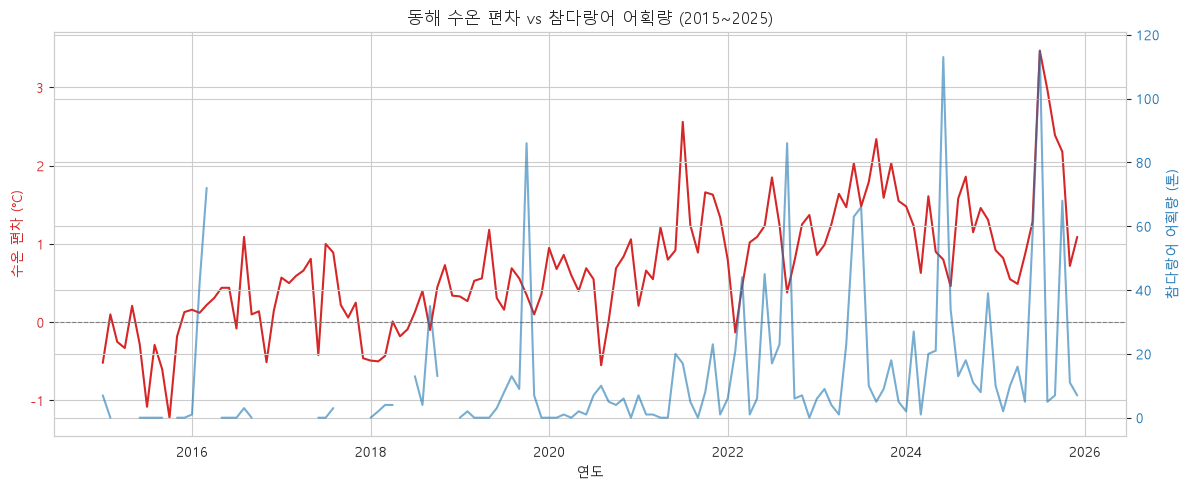

In [34]:
# 폰트 설정 (이 셀만 실행해도 한글이 깨지지 않도록 포함)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 날짜 컬럼 생성
merged_df["date"] = pd.to_datetime(merged_df[["year", "month"]].assign(day=1))

fig, ax1 = plt.subplots(figsize=(12, 5))

# 왼쪽 축: 수온 편차
ax1.plot(merged_df["date"], merged_df["donghae_anomaly"], color="tab:red", label="동해 수온 편차(°C)")
ax1.set_xlabel("연도")
ax1.set_ylabel("수온 편차 (°C)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.axhline(0, color="gray", linestyle="--", linewidth=0.8)

# 오른쪽 축: 참다랑어 어획량
ax2 = ax1.twinx()
ax2.plot(merged_df["date"], merged_df["tuna_catch"], color="tab:blue", alpha=0.6, label="참다랑어 어획량(톤)")
ax2.set_ylabel("참다랑어 어획량 (톤)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("동해 수온 편차 vs 참다랑어 어획량 (2015~2025)")
fig.tight_layout()
plt.show()

# 해석: 2020년 이후 동해 수온 편차가 전반적으로 상승하는 구간이 잦아지며,
# 같은 시기 참다랑어 어획량에서도 대규모 스파이크가 2015~2019년보다 
# 자주 관찰된다. 다만 월별 변동성이 매우 커서 육안으로는 정확한 상관관계를 
# 판단하기 어려우며, 다음 산점도 분석에서 수온-어획량 간 관계를 
# 정량적으로 확인한다.

### 6-2. 연도별 참다랑어(다랑어류) 어획량 추세

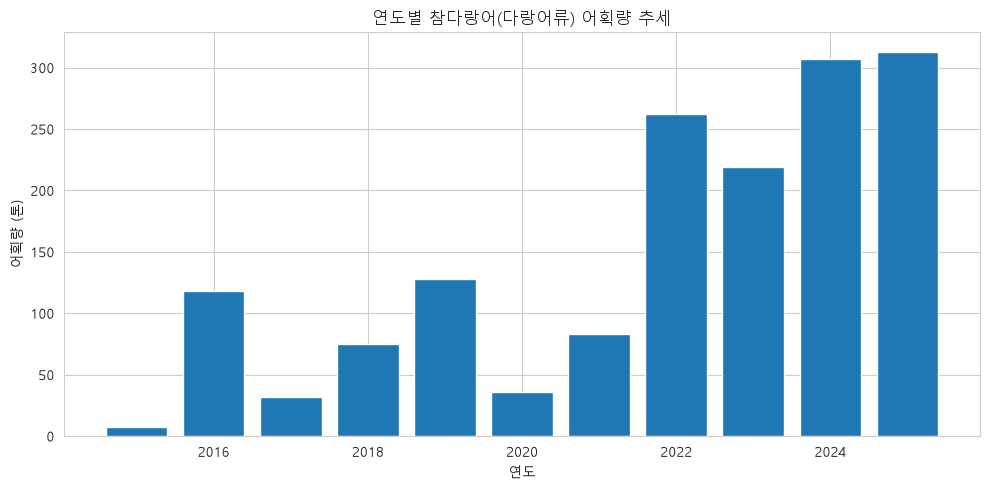

In [35]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

yearly_catch = merged_df.groupby("year", as_index=False)["tuna_catch"].sum(min_count=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly_catch["year"], yearly_catch["tuna_catch"], color="tab:blue")
ax.set_title("연도별 참다랑어(다랑어류) 어획량 추세")
ax.set_xlabel("연도")
ax.set_ylabel("어획량 (톤)")
plt.tight_layout()
plt.show()

# 해석: 참다랑어 어획량은 2015~2020년 대체로 0~130톤 수준에 머물다가, 
# 2022년 이후 250~300톤대로 뚜렷하게 증가한 뒤 그 수준을 유지하고 있다. 
# 이는 연도별 변동을 넘어선 구조적 증가로 해석될 여지가 있으며, 
# 동해 수온 상승 시점(6-1번 그래프)과 겹치는지 다음 산점도에서 확인한다.

## 6-3. 동해 수온과 참다랑어 어획량의 관계 (산점도)

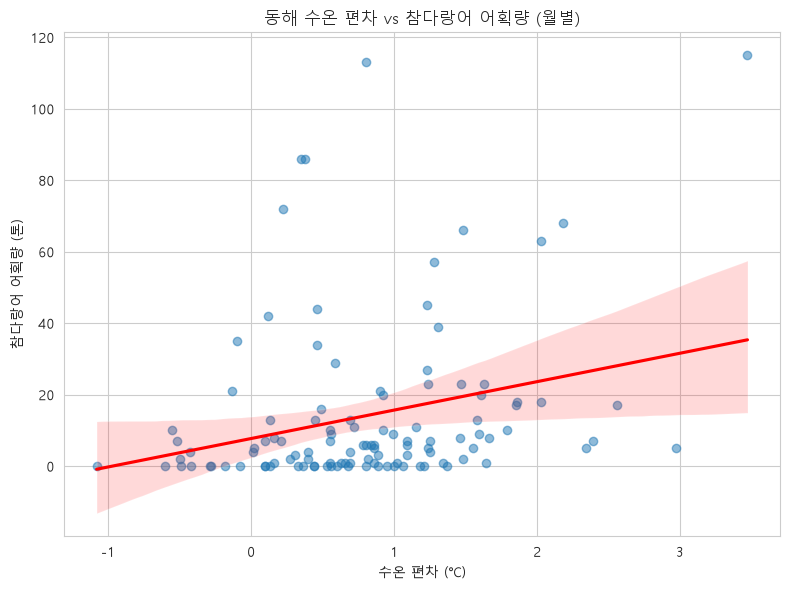

상관계수(r): 0.270


In [36]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=merged_df, x="donghae_anomaly", y="tuna_catch",
    scatter_kws={"alpha": 0.5}, line_kws={"color": "red"}, ax=ax
)
ax.set_title("동해 수온 편차 vs 참다랑어 어획량 (월별)")
ax.set_xlabel("수온 편차 (°C)")
ax.set_ylabel("참다랑어 어획량 (톤)")
plt.tight_layout()
plt.show()

valid = merged_df.dropna(subset=["donghae_anomaly", "tuna_catch"])
corr = valid["donghae_anomaly"].corr(valid["tuna_catch"])
print(f"상관계수(r): {corr:.3f}")

# 해석: 동해 수온 편차와 참다랑어 어획량 사이에는 약한 양의 상관관계(r=0.270)가 
# 확인된다. 특히 수온 편차가 1도 이상으로 높은 구간에서 100톤에 근접하는 
# 대규모 어획이 나타나는 반면, 수온 편차가 낮거나 음수인 구간에서는 
# 어획량이 대체로 0에 가깝게 유지된다. 다만 상관계수가 강하지 않다는 점에서, 
# 수온 외에도 어획량에 영향을 미치는 다른 요인(계절적 회유 패턴, 어업 노력량 등)이 
# 함께 작용하고 있을 가능성이 높으며, 본 분석만으로 인과관계를 단정할 수는 없다.

## 6-4. 월별 어획량 분포 (TAC 소진 시점 추정)

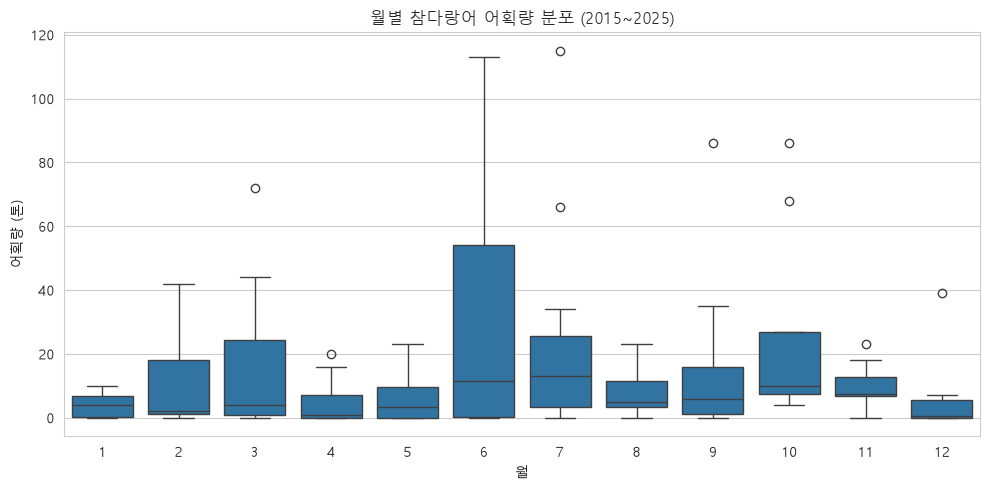

In [37]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=merged_df, x="month", y="tuna_catch", ax=ax)
ax.set_title("월별 참다랑어 어획량 분포 (2015~2025)")
ax.set_xlabel("월")
ax.set_ylabel("어획량 (톤)")
plt.tight_layout()
plt.show()

# 해석: 참다랑어 어획량은 6월에 변동폭 자체가 가장 크며(정상 범위 내 최대 약 110톤), 
# 7·9·10월에는 평소 범위를 크게 벗어나는 이상치(80~90톤대)가 관찰된다. 
# 1·2·4·12월은 어획량이 낮고 안정적이다. 이러한 계절적 집중 패턴은 
# 여름철 TAC 소진이 빠르게 진행된 뒤 하반기 어획이 제한되는 현상과 
# 시기적으로 겹칠 가능성을 시사하나, 실제 TAC 고시·소진 데이터를 
# 직접 확보하지 못해 이는 간접적 추정에 그친다.

## 6-5. (보조) 연도별 관련 논문 발표 수 추이 및 주요 키워드

bluefin tuna distribution climate change 200
fish stock shift warming ocean 200
adaptive TAC quota fisheries climate 200


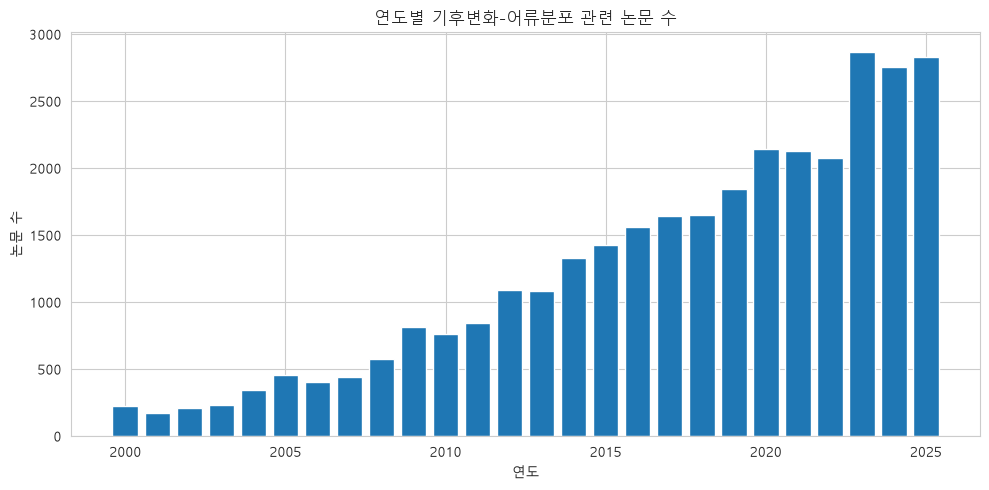

In [38]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

year_trend_records = []
for q in queries:
    resp = requests.get(
        openalex_url,
        params={"search": q, "group_by": "publication_year"},
        headers={"User-Agent": "mailto:your_email@example.com"},
    )
    print(q, resp.status_code)
    if resp.status_code == 200:
        groups = resp.json().get("group_by", [])
        for g in groups:
            year_trend_records.append({"query": q, "year": g["key"], "count": g["count"]})
    time.sleep(2)

year_trend_df = pd.DataFrame(year_trend_records)
year_trend_df["year"] = pd.to_numeric(year_trend_df["year"], errors="coerce")
year_trend_df = year_trend_df.dropna(subset=["year"])
year_trend_df["year"] = year_trend_df["year"].astype(int)
year_trend_df = year_trend_df[(year_trend_df["year"] >= 2000) & (year_trend_df["year"] <= 2025)]

year_total = year_trend_df.groupby("year", as_index=False)["count"].sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(year_total["year"], year_total["count"])
ax.set_title("연도별 기후변화-어류분포 관련 논문 수")
ax.set_xlabel("연도")
ax.set_ylabel("논문 수")
plt.tight_layout()
plt.show()

# 해석: 엥 너무 이쁘게 늘어나는거 같은데....하허허

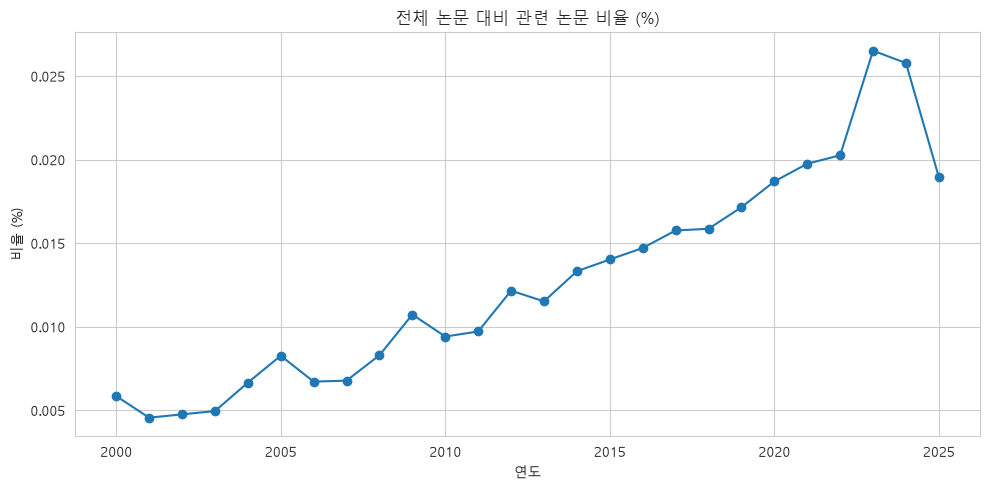

,year,count,key_display_name,total_count,ratio
0,2000,223,2000,3809081,0.005854
1,2001,174,2001,3816083,0.004560
2,2002,211,2002,4431713,0.004761
3,2003,234,2003,4722345,0.004955
4,2004,341,2004,5123885,0.006655
5,2005,452,2005,5466916,0.008268
6,2006,401,2006,5968652,0.006718
7,2007,440,2007,6492531,0.006777
8,2008,576,2008,6941722,0.008298
9,2009,811,2009,7555733,0.010734


In [39]:
# 검색어 없이 "전체 논문 수"의 연도별 추이를 받아서 비교 기준으로 삼기
resp = requests.get(
    openalex_url,
    params={"group_by": "publication_year"},
    headers={"User-Agent": "mailto:your_email@example.com"},
)
all_groups = resp.json().get("group_by", [])
baseline_df = pd.DataFrame(all_groups).rename(columns={"key": "year", "count": "total_count"})
baseline_df["year"] = pd.to_numeric(baseline_df["year"], errors="coerce")
baseline_df = baseline_df.dropna(subset=["year"])
baseline_df["year"] = baseline_df["year"].astype(int)
baseline_df = baseline_df[(baseline_df["year"] >= 2000) & (baseline_df["year"] <= 2025)]

# 우리 검색 결과와 병합해서 "비율"로 정규화
compare_df = year_total.merge(baseline_df, on="year")
compare_df["ratio"] = compare_df["count"] / compare_df["total_count"] * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(compare_df["year"], compare_df["ratio"], marker="o")
ax.set_title("전체 논문 대비 관련 논문 비율 (%)")
ax.set_xlabel("연도")
ax.set_ylabel("비율 (%)")
plt.tight_layout()
plt.show()

compare_df

# 해석: 전체 논문 대비 "참다랑어·기후변화·어류분포" 관련 논문의 비율은 
# 2000년 약 0.006%에서 2023년 약 0.025%로 4배 이상 증가했다. 
# 이는 전체 학술 출판량 증가와는 별개로, 이 주제에 대한 상대적 관심이 
# 뚜렷이 늘고 있음을 시사한다. 다만 2024~2025년 수치가 소폭 하락하는데, 
# 이는 최근 발표된 논문이 데이터베이스에 아직 완전히 색인되지 않았을 
# 가능성을 배제할 수 없어 최근 2개년 수치는 참고용으로만 해석한다.

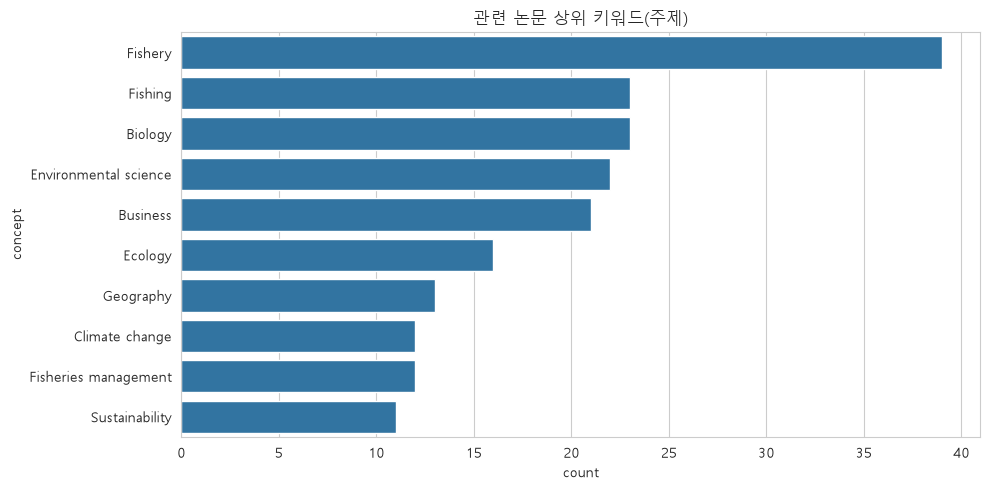

In [40]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from collections import Counter

all_concepts = []
for c_list in papers_clean_df["concepts"]:
    all_concepts.extend(c_list)

top_concepts = Counter(all_concepts).most_common(10)
concepts_df = pd.DataFrame(top_concepts, columns=["concept", "count"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=concepts_df, x="count", y="concept", ax=ax)
ax.set_title("관련 논문 상위 키워드(주제)")
plt.tight_layout()
plt.show()

# 해석: 상위 키워드에 Fishery, Business, Sustainability 등 다양한 주제가 
# 혼재되어 있어, 검색어로 수집한 논문 143편이 전부 "기후변화로 인한 
# 참다랑어 분포 변화"라는 좁은 주제에 부합한다고 보기는 어렵다. 양식업, 
# 수산 정책·경영 등 인접하지만 다른 세부 분야의 논문이 섞여 있을 가능성이 
# 높으며, 이는 검색어 기반 API 수집의 근본적 한계다. 따라서 이 키워드 
# 목록과 논문 수 트렌드는 "학계의 넓은 관심 방향"을 보여주는 참고 자료로만 
# 해석하며, 참다랑어 분포 변화에 대한 직접적 정량 근거로는 사용하지 않는다.

## 7. 마무리 정리

**처음 질문**: 동해 표층수온 상승 추세와 참다랑어(다랑어류) 어획량 증가 추세는 함께 나타나는가, 
그리고 그 증가가 현행 TAC 소진 시점과 시기적으로 충돌하는가?

**그린 그래프**
1. 연도별 동해 수온 편차 vs 참다랑어 어획량 (월별 라인)
2. 연도별 참다랑어 어획량 추세 (막대그래프)
3. 동해 수온 편차 vs 참다랑어 어획량 산점도 + 회귀선 (r=0.270)
4. 월별 참다랑어 어획량 분포 (boxplot, TAC 소진 시점 추정)
5. (보조) 전체 논문 대비 관련 논문 비율 추이
6. (보조, 검증용) 관련 논문 상위 키워드

**알게 된 점**
- 참다랑어 어획량은 2022년 이후 250~300톤대로 뚜렷하게 증가했으며, 이는 동해 수온이 
  전반적으로 상승 추세를 보인 시기와 겹친다.
- 수온 편차와 어획량 사이에는 약한 양의 상관관계(r=0.270)가 확인되나, 강한 상관은 아니다.
- 어획은 6월에 변동성이 가장 크고, 7·9·10월에 이례적인 대량 어획(이상치)이 관찰되어, 
  여름~초가을에 어획이 집중되는 계절성이 뚜렷하다. 이는 TAC 소진이 하반기 어획 제한으로 
  이어질 가능성을 시사하나, 실제 TAC 고시·소진 데이터로 직접 검증하지는 못했다.
- 관련 학술 논문의 비율도 2000년 대비 2023년 4배 이상 증가해, 이 주제에 대한 학계 관심이 
  실제로 늘고 있음을 뒷받침한다.

**이번 분석이 보여주지 못한 것 (한계)**
- 수온-어획량 간 상관관계는 확인했으나 인과관계까지는 증명하지 못했다.
- TAC 실제 고시량·소진 시점 데이터를 확보하지 못해, 월별 어획 집중 패턴으로 간접 추정만 했다.
- KOSIS 데이터는 일부 월의 값이 원천적으로 결측(컬럼 자체 부재)이라, 결측을 진짜 0과 
  구분하기 위해 전체 연-월 축을 만들어 통일 처리했다.
- 논문 키워드 분석 결과 Business, Sustainability 등 이질적 주제가 섞여 있어, 
  검색어 기반 수집이 완전히 좁은 주제(참다랑어 분포 변화)만 포착했다고 보기는 어렵다. 
  이는 학계의 넓은 관심 방향을 보여주는 참고 자료로만 해석한다.
- 향후 GAM/MaxEnt 기반 동적 분포모델로 확장 시, 수온·염분·먹이생물(멸치 등) 데이터와 
  실제 어선 위치 기반 회유 경로 자료가 추가로 필요하다.

## 8. 윤리 점검 리포트

**1. 수집 개요**
- 동해 표층수온: oceanclimate.kr, `requests` + `BeautifulSoup`로 직접 스크래핑 (var=mean, var=anom 각각 요청)
- 참다랑어(다랑어류) 어획량: KOSIS 어업생산동향조사, 조회 결과가 2만 셀을 초과하여 
  화면 조회/오픈API 대신 공식 CSV 다운로드 기능 사용
- 관련 논문 메타데이터: OpenAlex 공식 오픈 API (`requests`)

**2. 수집 결과**
- 수온: 257개월 (2005.01~2026.05), 결측 0건
- 어획량: 132개월(동해권 3개 도 합산), 원천 결측 다수 → 전체 연-월 축 생성 후 결측 통일 처리
- 논문: 143편 (3개 검색어, 중복 제거 후)

**3. 데이터 신뢰성**
- 스크래핑 추출 행 수를 매 요청마다 `len()`으로 검증함 (조용한 실패 방지).
- 결측치는 "-"(KOSIS) 및 컬럼 자체 부재를 동일하게 NaN으로 통일 처리하고 근거를 기록함.
- 논문 트렌드는 절대 수치가 아닌 "전체 논문 대비 비율"로 재검증하여, 전체 학술 출판량 
  증가라는 배경 잡음을 제거함.

**4. 윤리 점검**
- oceanclimate.kr: robots.txt 확인, 요청 간 `time.sleep()` 적용, User-Agent 명시
- KOSIS: 조회 셀 제한으로 인해 스크래핑 대신 공식 CSV 다운로드 사용 (정당한 사유)
- OpenAlex: 공식 오픈 API, 요청 간 `time.sleep(2)` 적용
- Google Scholar는 robots.txt·이용약관상 자동화 접근이 명시적으로 금지되어 있어 
  수집 대상에서 제외하고, 대신 OpenAlex를 사용함
- 로그인 필요 페이지, 개인정보 미수집